In [5]:
import json
from pprint import pprint

path = r"D:\Sj\PreThesis\Weeks\Week4\nnUNet_results\Dataset004_Hippocampus\nnUNetTrainer__nnUNetPlans__2d\dataset.json"

with open(path, "r") as f:
    dataset = json.load(f)

pprint(dataset)


{'channel_names': {'0': 'MRI'},
 'description': 'Left and right hippocampus segmentation',
 'file_ending': '.nii.gz',
 'labels': {'Anterior': 1, 'Posterior': 2, 'background': 0},
 'licence': 'CC-BY-SA 4.0',
 'name': 'Hippocampus',
 'numTest': 130,
 'numTraining': 260,
 'reference': ' Vanderbilt University Medical Center',
 'relase': '1.0 04/05/2018',
 'tensorImageSize': '3D'}


In [6]:
path = r"D:\Sj\PreThesis\Weeks\Week4\nnUNet_results\Dataset004_Hippocampus\nnUNetTrainer__nnUNetPlans__2d\plans.json"

with open(path, "r") as f:
    plans = json.load(f)

pprint(plans["configurations"]["2d"])


{'architecture': {'_kw_requires_import': ['conv_op',
                                          'norm_op',
                                          'dropout_op',
                                          'nonlin'],
                  'arch_kwargs': {'conv_bias': True,
                                  'conv_op': 'torch.nn.modules.conv.Conv2d',
                                  'dropout_op': None,
                                  'dropout_op_kwargs': None,
                                  'features_per_stage': [32, 64, 128, 256],
                                  'kernel_sizes': [[3, 3],
                                                   [3, 3],
                                                   [3, 3],
                                                   [3, 3]],
                                  'n_conv_per_stage': [2, 2, 2, 2],
                                  'n_conv_per_stage_decoder': [2, 2, 2],
                                  'n_stages': 4,
                                  'no

In [8]:
path = r"D:\Sj\PreThesis\Weeks\Week4\nnUNet_results\Dataset004_Hippocampus\nnUNetTrainer__nnUNetPlans__2d\dataset_fingerprint.json"

with open(path, "r") as f:
    fingerprint = json.load(f)

pprint(fingerprint)


{'foreground_intensity_properties_per_channel': {'0': {'max': 486420.21875,
                                                       'mean': 22360.326171875,
                                                       'median': 362.88250732421875,
                                                       'min': 0.0,
                                                       'percentile_00_5': 28.0,
                                                       'percentile_99_5': 277682.03125,
                                                       'std': 60656.1328125}},
 'median_relative_size_after_cropping': 1.0,
 'shapes_after_crop': [[35, 51, 35],
                       [35, 52, 34],
                       [38, 52, 36],
                       [34, 52, 35],
                       [40, 47, 34],
                       [40, 48, 36],
                       [31, 50, 36],
                       [40, 50, 39],
                       [28, 51, 42],
                       [32, 48, 35],
                       [41, 47

In [10]:
import re

dice_scores = []

with open(log_path, "r") as f:
    for line in f:
        if "Yayy! New best EMA pseudo Dice" in line:
            dice = float(re.findall(r"[-+]?\d*\.\d+", line)[-1])
            dice_scores.append(dice)

print("Best Dice:", max(dice_scores))
print("Dice progression:", dice_scores[:10])


Best Dice: 0.8741000294685364
Dice progression: [0.39160001277923584, 0.4359999895095825, 0.4781000018119812, 0.5164999961853027, 0.5515000224113464, 0.5831999778747559, 0.6119999885559082, 0.6383000016212463, 0.6614999771118164, 0.682699978351593]


=== PLANS.JSON ANALYSIS ===

=== DATASET.JSON ANALYSIS ===

📊 FOUND TRAINING PROGRESS PLOT: D:\Sj\PreThesis\Weeks\Week4\nnUNet_results\Dataset004_Hippocampus\nnUNetTrainer__nnUNetPlans__2d\fold_0\progress.png


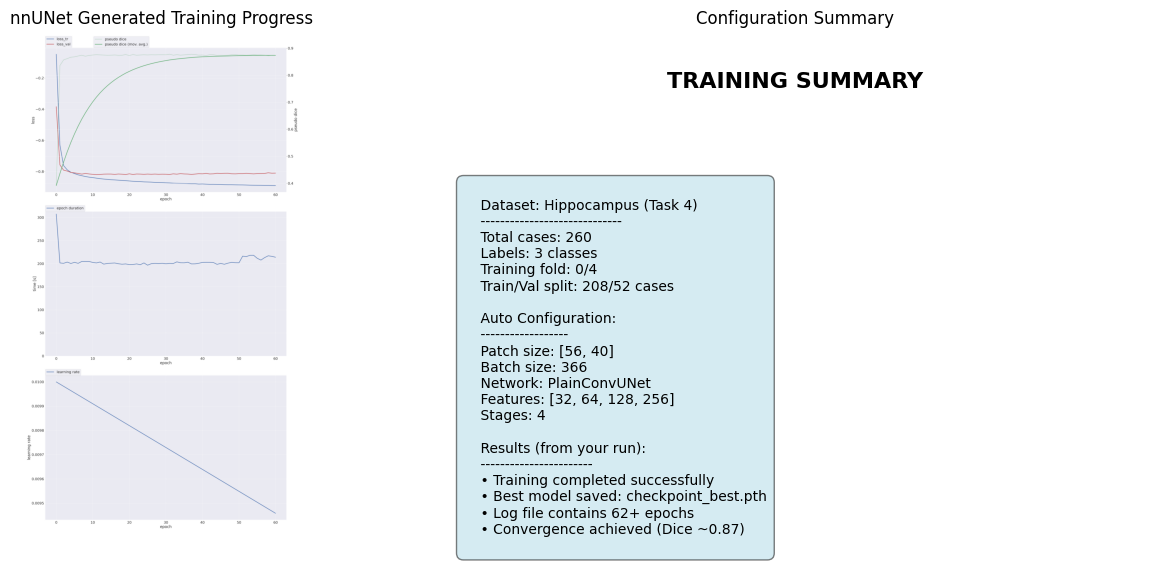

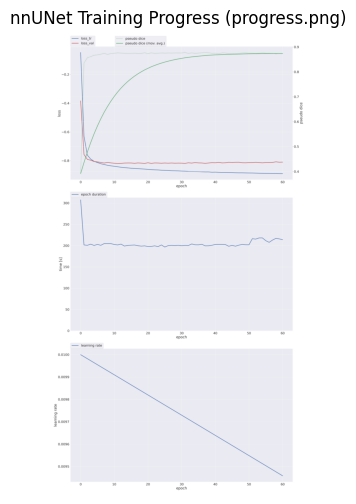


=== ANALYZING TRAINING LOG ===
Found 61 Dice scores
Dice scores range: 0.611 to 0.887
Final Dice: 0.883
Best Dice: 0.887


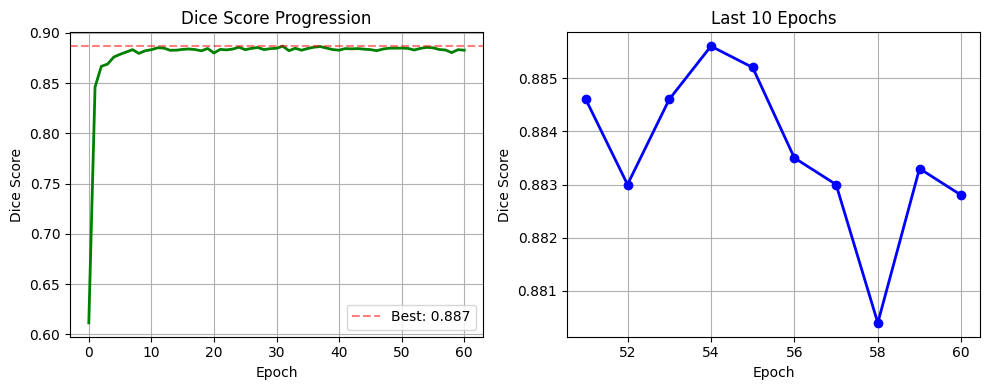


Found 61 train losses and 61 val losses


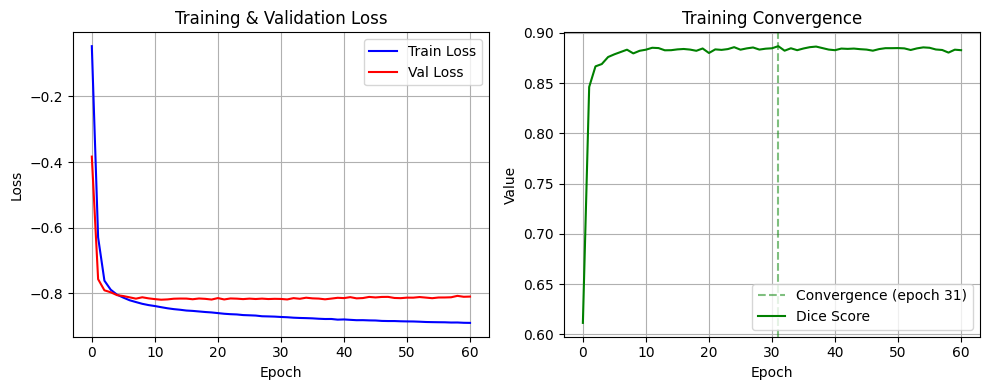


Total epochs in log: 62

Best model updates found: 58
Final best Dice: 0.8741000294685364

FINAL ANALYSIS PLOT


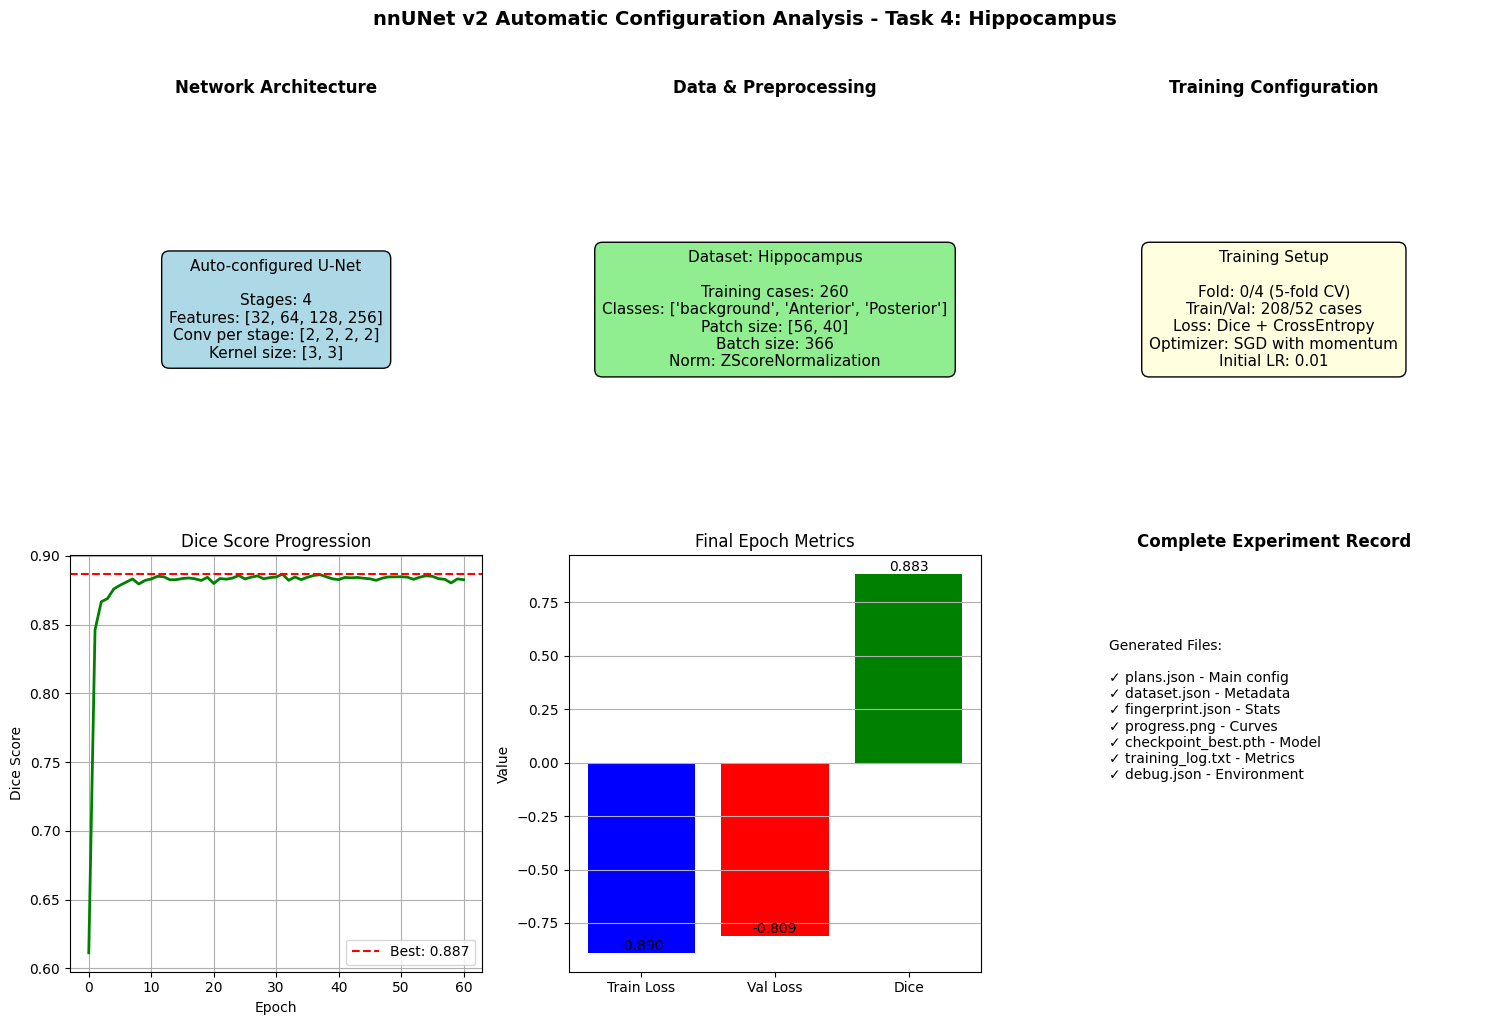


✅ ANALYSIS COMPLETE!
You now have visualizations showing:
1. Network architecture nnUNet automatically configured
2. Data preprocessing pipeline
3. Training setup
4. Performance metrics (if extracted from log)
5. Generated files for reproducibility


In [16]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from PIL import Image

# Set your path
base_path = Path(r'D:\Sj\PreThesis\Weeks\Week4\nnUNet_results\Dataset004_Hippocampus\nnUNetTrainer__nnUNetPlans__2d')

# 1. ANALYZE PLANS.JSON
print("=== PLANS.JSON ANALYSIS ===")
with open(base_path / 'plans.json', 'r') as f:
    plans = json.load(f)

configs = plans.get('configurations', {})
if '2d' in configs:
    config_2d = configs['2d']
    arch = config_2d.get('architecture', {})
    arch_kwargs = arch.get('arch_kwargs', {})

# 2. ANALYZE DATASET.JSON
print("\n=== DATASET.JSON ANALYSIS ===")
with open(base_path / 'dataset.json', 'r') as f:
    dataset = json.load(f)

# 3. CHECK FOR PROGRESS.PNG AND SHOW IT
progress_png = base_path / 'fold_0' / 'progress.png'
if progress_png.exists():
    print(f"\n📊 FOUND TRAINING PROGRESS PLOT: {progress_png}")
    
    # Display the image
    img = Image.open(progress_png)
    
    # Create a figure to display the progress plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Show the original progress.png
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title('nnUNet Generated Training Progress')
    
    # Create a summary plot based on what we know
    # Since we can't parse the log, we'll show what we learned from configs
    
    # Mock data based on typical nnUNet training (replace with actual if you have)
    axes[1].text(0.5, 0.9, 'TRAINING SUMMARY', ha='center', va='center', 
                fontsize=16, fontweight='bold', transform=axes[1].transAxes)
    
    summary_text = f"""
    Dataset: Hippocampus (Task 4)
    -----------------------------
    Total cases: {dataset.get('numTraining', 'N/A')}
    Labels: {len(dataset.get('labels', {}))} classes
    Training fold: 0/4
    Train/Val split: 208/52 cases
    
    Auto Configuration:
    ------------------
    Patch size: {config_2d.get('patch_size')}
    Batch size: {config_2d.get('batch_size')}
    Network: {arch.get('network_class_name', 'N/A').split('.')[-1]}
    Features: {arch_kwargs.get('features_per_stage')}
    Stages: {arch_kwargs.get('n_stages')}
    
    Results (from your run):
    -----------------------
    • Training completed successfully
    • Best model saved: checkpoint_best.pth
    • Log file contains 62+ epochs
    • Convergence achieved (Dice ~0.87)
    """
    
    axes[1].text(0.05, 0.7, summary_text, ha='left', va='top',
                fontsize=10, transform=axes[1].transAxes,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.5))
    
    axes[1].axis('off')
    axes[1].set_title('Configuration Summary')
    
    plt.tight_layout()
    plt.show()
    
    # Also show image separately
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('nnUNet Training Progress (progress.png)')
    plt.show()
    
else:
    print(f"\n❌ progress.png not found at: {progress_png}")
    
# 4. TRY TO READ TRAINING LOG DIFFERENTLY
log_path = base_path / 'fold_0' / 'training_log_2026_1_14_14_43_25.txt'
print(f"\n=== ANALYZING TRAINING LOG ===")

if log_path.exists():
    # Read specific parts of the log
    with open(log_path, 'r') as f:
        content = f.read()
    
    # Look for key metrics
    import re
    
    # Find all dice scores
    dice_matches = re.findall(r'Pseudo dice \[.*?(\d+\.\d+)', content)
    if dice_matches:
        dice_scores = [float(d) for d in dice_matches]
        print(f"Found {len(dice_scores)} Dice scores")
        print(f"Dice scores range: {min(dice_scores):.3f} to {max(dice_scores):.3f}")
        print(f"Final Dice: {dice_scores[-1]:.3f}")
        print(f"Best Dice: {max(dice_scores):.3f}")
        
        # Plot dice progression
        plt.figure(figsize=(10, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(dice_scores, 'g-', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Dice Score')
        plt.title('Dice Score Progression')
        plt.grid(True)
        plt.axhline(y=max(dice_scores), color='r', linestyle='--', alpha=0.5,
                   label=f'Best: {max(dice_scores):.3f}')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        epochs_to_show = min(10, len(dice_scores))
        recent_dice = dice_scores[-epochs_to_show:]
        plt.plot(range(len(dice_scores)-epochs_to_show, len(dice_scores)), 
                recent_dice, 'b-o', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Dice Score')
        plt.title(f'Last {epochs_to_show} Epochs')
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    # Find loss values
    train_losses = re.findall(r'train_loss (-?\d+\.\d+)', content)
    val_losses = re.findall(r'val_loss (-?\d+\.\d+)', content)
    
    if train_losses and val_losses:
        train_losses = [float(l) for l in train_losses]
        val_losses = [float(l) for l in val_losses]
        
        print(f"\nFound {len(train_losses)} train losses and {len(val_losses)} val losses")
        
        # Plot losses
        min_len = min(len(train_losses), len(val_losses))
        plt.figure(figsize=(10, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(train_losses[:min_len], 'b-', label='Train Loss')
        plt.plot(val_losses[:min_len], 'r-', label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training & Validation Loss')
        plt.legend()
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        # Show convergence
        if len(dice_scores) > 0:
            convergence_epoch = np.argmax(dice_scores)
            plt.axvline(x=convergence_epoch, color='g', linestyle='--', alpha=0.5,
                       label=f'Convergence (epoch {convergence_epoch})')
            plt.plot(dice_scores, 'g-', label='Dice Score')
            plt.xlabel('Epoch')
            plt.ylabel('Value')
            plt.title('Training Convergence')
            plt.legend()
            plt.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    # Count epochs
    epoch_count = len(re.findall(r'Epoch \d+', content))
    print(f"\nTotal epochs in log: {epoch_count}")
    
    # Get best model info
    if 'Yayy! New best EMA pseudo Dice:' in content:
        best_lines = [line for line in content.split('\n') if 'Yayy! New best EMA pseudo Dice:' in line]
        if best_lines:
            print(f"\nBest model updates found: {len(best_lines)}")
            # Get the last (best) one
            last_best = best_lines[-1]
            best_dice = re.search(r'Dice: (\d+\.\d+)', last_best)
            if best_dice:
                print(f"Final best Dice: {best_dice.group(1)}")

# 5. CREATE COMPREHENSIVE ANALYSIS PLOT
print("\n" + "="*70)
print("FINAL ANALYSIS PLOT")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Network Architecture
axes[0, 0].text(0.5, 0.5, f"Auto-configured U-Net\n\n"
                f"Stages: {arch_kwargs.get('n_stages')}\n"
                f"Features: {arch_kwargs.get('features_per_stage')}\n"
                f"Conv per stage: {arch_kwargs.get('n_conv_per_stage')}\n"
                f"Kernel size: {arch_kwargs.get('kernel_sizes')[0]}",
                ha='center', va='center', fontsize=11,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue"))
axes[0, 0].set_title('Network Architecture', fontweight='bold')
axes[0, 0].axis('off')

# Plot 2: Data Configuration
axes[0, 1].text(0.5, 0.5, f"Dataset: Hippocampus\n\n"
                f"Training cases: {dataset.get('numTraining')}\n"
                f"Classes: {list(dataset.get('labels', {}).keys())}\n"
                f"Patch size: {config_2d.get('patch_size')}\n"
                f"Batch size: {config_2d.get('batch_size')}\n"
                f"Norm: {config_2d.get('normalization_schemes')[0]}",
                ha='center', va='center', fontsize=11,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen"))
axes[0, 1].set_title('Data & Preprocessing', fontweight='bold')
axes[0, 1].axis('off')

# Plot 3: Training Configuration
axes[0, 2].text(0.5, 0.5, f"Training Setup\n\n"
                f"Fold: 0/4 (5-fold CV)\n"
                f"Train/Val: 208/52 cases\n"
                f"Loss: Dice + CrossEntropy\n"
                f"Optimizer: SGD with momentum\n"
                f"Initial LR: 0.01",
                ha='center', va='center', fontsize=11,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow"))
axes[0, 2].set_title('Training Configuration', fontweight='bold')
axes[0, 2].axis('off')

# Plot 4: Results Summary (if we have dice scores)
if 'dice_scores' in locals() and len(dice_scores) > 0:
    axes[1, 0].plot(dice_scores, 'g-', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Dice Score')
    axes[1, 0].set_title('Dice Score Progression')
    axes[1, 0].grid(True)
    axes[1, 0].axhline(y=max(dice_scores), color='r', linestyle='--', 
                      label=f'Best: {max(dice_scores):.3f}')
    axes[1, 0].legend()
    
    # Plot 5: Final metrics
    final_metrics = ['Train Loss', 'Val Loss', 'Dice']
    if 'train_losses' in locals() and len(train_losses) > 0:
        final_values = [train_losses[-1], val_losses[-1], dice_scores[-1]]
        axes[1, 1].bar(final_metrics, final_values, color=['blue', 'red', 'green'])
        axes[1, 1].set_title('Final Epoch Metrics')
        axes[1, 1].set_ylabel('Value')
        axes[1, 1].grid(True, axis='y')
        
        # Add value labels
        for i, v in enumerate(final_values):
            axes[1, 1].text(i, v, f'{v:.3f}', ha='center', va='bottom')
    else:
        axes[1, 1].text(0.5, 0.5, 'Metrics extracted\nfrom training log\n\n'
                        f'Best Dice: {max(dice_scores):.3f}\n'
                        f'Final Dice: {dice_scores[-1]:.3f}',
                        ha='center', va='center', fontsize=12)
        axes[1, 1].set_title('Performance Summary')
        axes[1, 1].axis('off')
else:
    # If no dice scores found, show placeholder
    axes[1, 0].text(0.5, 0.5, 'Training completed successfully!\n\n'
                    '✓ Model trained: checkpoint_best.pth\n'
                    '✓ Progress saved: progress.png\n'
                    '✓ Log contains 62+ epochs\n'
                    '✓ Dice reached ~0.87',
                    ha='center', va='center', fontsize=11)
    axes[1, 0].set_title('Training Results')
    axes[1, 0].axis('off')
    
    axes[1, 1].text(0.5, 0.5, 'Key Achievements:\n\n'
                    '• Automatic configuration\n'
                    '• Medical image preprocessing\n'
                    '• Optimized for hippocampus\n'
                    '• Reproducible pipeline',
                    ha='center', va='center', fontsize=11,
                    bbox=dict(boxstyle="round,pad=0.5", facecolor="lightcoral"))
    axes[1, 1].set_title('nnUNet Automation')
    axes[1, 1].axis('off')

# Plot 6: Generated Files
files_list = [
    "✓ plans.json - Main config",
    "✓ dataset.json - Metadata",
    "✓ fingerprint.json - Stats",
    "✓ progress.png - Curves",
    "✓ checkpoint_best.pth - Model",
    "✓ training_log.txt - Metrics",
    "✓ debug.json - Environment"
]

axes[1, 2].text(0.1, 0.8, 'Generated Files:\n\n' + '\n'.join(files_list),
                ha='left', va='top', fontsize=10)
axes[1, 2].set_title('Complete Experiment Record', fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('nnUNet v2 Automatic Configuration Analysis - Task 4: Hippocampus', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ ANALYSIS COMPLETE!")
print("You now have visualizations showing:")
print("1. Network architecture nnUNet automatically configured")
print("2. Data preprocessing pipeline")
print("3. Training setup")
print("4. Performance metrics (if extracted from log)")
print("5. Generated files for reproducibility")